## Segmentation using UNet architecture in PyTorch

In [ ]:
from torch import nn
import torch
import torchvision as tv
import os
import glob
from PIL import Image
import math
import torchvision.transforms as transforms
import random
import numpy as np
from datetime import datetime

In [ ]:
CLASSES = ["Lemon", "Dolphin", "Clock"]
MAX_SAMPLES_PER_CLASS = 500
DATA_DIR = "drive/MyDrive/data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 20
WORKER_COUNT = 2
LEARNING_RATE = 1e-4
EPOCH_COUNT = 50

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !pip install fiftyone

# import fiftyone as fo
# import fiftyone.zoo as foz

# # download datasets to "data" folder
# def download_openimages_segmentations(classes, max_samples_per_class, data_dir):
#     # create folder "data" if not created
#     if not os.path.exists("data"):
#         os.mkdir("data")
#     for class_name in classes:
#         # get metadata of dataset
#         dataset = foz.load_zoo_dataset(
#             name="open-images-v7",
#             classes=[class_name],
#             label_types=["segmentations"],
#             max_samples=max_samples_per_class,
#             dataset_name=f"open-images-v7-{class_name}-{max_samples_per_class}")
#         # filter dataset to only leave segmentations of target classes
#         for sample in dataset:
#             detections = sample.ground_truth.detections
#             if len(detections) > 1:
#                 target_class_detections = []
#                 for i, detection in enumerate(sample.ground_truth.detections):
#                     if detection.label == class_name:
#                         target_class_detections.append(sample.ground_truth.detections[i])
#                 sample.ground_truth.set_field("detections", target_class_detections)
#                 sample.save()
#         # save filtered dataset to disk directory
#         dataset.export(
#             export_dir=f"{data_dir}/{class_name}",
#             dataset_type=fo.types.ImageSegmentationDirectory,
#             label_field="ground_truth"
#         )

# download_openimages_segmentations(CLASSES, MAX_SAMPLES_PER_CLASS, DATA_DIR)

In [ ]:
class SegmentationDataset(torch.utils.data.Dataset):
  def __init__(self, img_mask_class_list, is_train=False):
    # (img_path, mask_path, true_class_index) pairs
    self.img_mask_class_list = img_mask_class_list
    self.is_train = is_train

  def __len__(self):
    return len(self.img_mask_class_list)

  def __getitem__(self, index):
    compatible_img_mask = self.get_compatible_img_mask(
        self.img_mask_class_list[index]
    )
    return compatible_img_mask

  @classmethod
  def from_dir(cls, dir_path, classes):
    img_mask_class_list = []
    for class_index, class_name in enumerate(classes):
      image_paths = glob.glob("{}/{}/data/*.jpg".format(dir_path, class_name))
      mask_paths = glob.glob("{}/{}/labels/*.png".format(dir_path, class_name))
      image_paths.sort()
      mask_paths.sort()
      # limit number of samples
      image_paths = image_paths[:MAX_SAMPLES_PER_CLASS]
      mask_paths = mask_paths[:MAX_SAMPLES_PER_CLASS]
      for i in range(len(image_paths)):
        img_mask_class_list.append((image_paths[i], mask_paths[i], class_index))
    return cls(img_mask_class_list)

  def get_compatible_img_mask(self, img_mask_class):
    img_path, mask_path, class_index = img_mask_class
    img = Image.open(img_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    transformed_img, transformed_mask = self.transform(img, mask)
    mask_class_tensor = torch.zeros((3, transformed_mask.shape[1], transformed_mask.shape[2]))
    # copy the mask to the channel index of the class index
    mask_class_tensor[class_index] = torch.clone(transformed_mask[0])
    return (transformed_img, mask_class_tensor, class_index)

  def transform(self, img, mask):
    if self.is_train:
      pad_x = math.ceil(max(0, 256 - img.width) / 2)
      pad_y = math.ceil(max(0, 256 - img.height) / 2)
      img = transforms.functional.pad(img, [pad_x, pad_y])
      mask = transforms.functional.pad(mask, [pad_x, pad_y])
      crop_params = transforms.RandomCrop.get_params(img, output_size = (256, 256))
      img = transforms.functional.crop(img, *crop_params)
      mask = transforms.functional.crop(mask, *crop_params)
      # random horizontal flip
      if random.random() > 0.5:
        img = transforms.functional.hflip(img)
        mask = transforms.functional.hflip(mask)
      # random rotation
      angle = random.uniform(-30, 30)
      img = transforms.functional.rotate(img, angle)
      mask = transforms.functional.rotate(mask, angle)
      # random gaussian blur
      if random.random() > 0.5:
        img = transforms.functional.gaussian_blur(img, kernel_size=3)
      # random color jitter
      if random.random() > 0.5:
        img = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)(img)
      # random gamma
      if random.random() > 0.5:
        img = transforms.functional.adjust_gamma(img, gamma=random.uniform(0.8, 1.2))
    else:
      img = transforms.functional.resize(img, (256, 256))
      mask = transforms.functional.resize(mask, (256, 256))
    # common
    img = transforms.functional.to_tensor(img)
    img = transforms.functional.normalize(img, (0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    mask = transforms.functional.to_tensor(mask)
    return (img, mask)

  def split(self, seed=4, train_percent=0.8):
    train_dataset_size = int(train_percent * len(self))
    img_mask_class_list = self.img_mask_class_list.copy()
    # split on shuffled data
    random.Random(seed).shuffle(img_mask_class_list)
    train_dataset = SegmentationDataset(img_mask_class_list[:train_dataset_size], is_train=True)
    test_dataset = SegmentationDataset(img_mask_class_list[train_dataset_size:])
    return (train_dataset, test_dataset)

In [ ]:
train_dataset, test_dataset = SegmentationDataset \
  .from_dir(DATA_DIR, CLASSES) \
  .split(seed=5, train_percent=0.8)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=WORKER_COUNT, shuffle=True, pin_memory=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=WORKER_COUNT, shuffle=False, pin_memory=False)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
class EncodingBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
      super(EncodingBlock, self).__init__()
      self.conv = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
      )
    def forward(self, x):
      return self.conv(x)

In [ ]:
class UNet(nn.Module):
  def __init__(self, in_channels, out_channels, features=[64, 128, 256, 512]):
    super(UNet, self).__init__()
    self.pool = nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))
    self.conv1 = EncodingBlock(in_channels, features[0])
    self.conv2 = EncodingBlock(features[0], features[1])
    self.conv3 = EncodingBlock(features[1], features[2])
    self.conv4 = EncodingBlock(features[2], features[3])
    self.conv5 = EncodingBlock(features[3]*2, features[3])
    self.conv6 = EncodingBlock(features[3], features[2])
    self.conv7 = EncodingBlock(features[2], features[1])
    self.conv8 = EncodingBlock(features[1], features[0])
    self.tconv1 = nn.ConvTranspose2d(features[-1]*2, features[-1], kernel_size=2, stride=2)
    self.tconv2 = nn.ConvTranspose2d(features[-1], features[-2], kernel_size=2, stride=2)
    self.tconv3 = nn.ConvTranspose2d(features[-2], features[-3], kernel_size=2, stride=2)
    self.tconv4 = nn.ConvTranspose2d(features[-3], features[-4], kernel_size=2, stride=2)
    self.bottleneck = EncodingBlock(features[3], features[3]*2)
    self.final_layer = nn.Conv2d(features[0], out_channels, kernel_size=1)
  def forward(self,x):
    skip_connections = []
    x = self.conv1(x)
    skip_connections.append(x)
    x = self.pool(x)
    x = self.conv2(x)
    skip_connections.append(x)
    x = self.pool(x)
    x = self.conv3(x)
    skip_connections.append(x)
    x = self.pool(x)
    x = self.conv4(x)
    skip_connections.append(x)
    x = self.pool(x)
    x = self.bottleneck(x)
    skip_connections = skip_connections[::-1]
    x = self.tconv1(x)
    x = torch.cat((skip_connections[0], x), dim=1)
    x = self.conv5(x)
    x = self.tconv2(x)
    x = torch.cat((skip_connections[1], x), dim=1)
    x = self.conv6(x)
    x = self.tconv3(x)
    x = torch.cat((skip_connections[2], x), dim=1)
    x = self.conv7(x)
    x = self.tconv4(x)
    x = torch.cat((skip_connections[3], x), dim=1)
    x = self.conv8(x)
    x = self.final_layer(x)
    return x

model = UNet(in_channels=3, out_channels=3).to(DEVICE)

In [ ]:
from torchsummary import summary
summary(model, (3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 256, 256]           1,728
       BatchNorm2d-2         [-1, 64, 256, 256]             128
              ReLU-3         [-1, 64, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          36,864
       BatchNorm2d-5         [-1, 64, 256, 256]             128
              ReLU-6         [-1, 64, 256, 256]               0
     EncodingBlock-7         [-1, 64, 256, 256]               0
         MaxPool2d-8         [-1, 64, 128, 128]               0
            Conv2d-9        [-1, 128, 128, 128]          73,728
      BatchNorm2d-10        [-1, 128, 128, 128]             256
             ReLU-11        [-1, 128, 128, 128]               0
           Conv2d-12        [-1, 128, 128, 128]         147,456
      BatchNorm2d-13        [-1, 128, 128, 128]             256
             ReLU-14        [-1, 128, 1

In [ ]:
def train(model, loader, class_count, epoch_count=20, learning_rate=1e-4, step_size=10, gamma=0.1):
  loss_function = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
  model.train()
  start_time = datetime.now()
  for epoch in range(epoch_count):
    loss_acumulator = np.empty(len(loader), dtype=np.float32)
    i = 0
    for inputs, labels, _ in loader:
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)
      next_i = i + inputs.shape[0]
      predictions = model(inputs)
      loss = loss_function(predictions, labels)
      loss_acumulator[i : next_i] = loss.cpu().detach().numpy()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      i = next_i
    scheduler.step()
    current_time = datetime.now()
    print(f'Epoch: {epoch}, Time: {current_time - start_time}, Loss: {np.mean(loss_acumulator)}, LR: {scheduler.get_last_lr()}')
    start_time = current_time

train(model, train_loader, len(CLASSES), EPOCH_COUNT, LEARNING_RATE)

Epoch: 0, Time: 0:09:00.042764, Loss: 0.14974187314510345, LR: [0.0001]
Epoch: 1, Time: 0:01:09.712669, Loss: 0.1412399262189865, LR: [0.0001]
Epoch: 2, Time: 0:01:09.213040, Loss: 0.06897863000631332, LR: [0.0001]
Epoch: 3, Time: 0:01:08.871759, Loss: 0.1225639060139656, LR: [0.0001]
Epoch: 4, Time: 0:01:08.777325, Loss: 0.06493218243122101, LR: [0.0001]
Epoch: 5, Time: 0:01:09.822868, Loss: 0.18821296095848083, LR: [0.0001]
Epoch: 6, Time: 0:01:08.902354, Loss: 0.05413227900862694, LR: [0.0001]
Epoch: 7, Time: 0:01:08.836193, Loss: 0.11813684552907944, LR: [0.0001]
Epoch: 8, Time: 0:01:09.647387, Loss: 0.08138266950845718, LR: [0.0001]
Epoch: 9, Time: 0:01:08.758708, Loss: 0.14109355211257935, LR: [1e-05]
Epoch: 10, Time: 0:01:08.842946, Loss: 0.0858842059969902, LR: [1e-05]
Epoch: 11, Time: 0:01:08.772574, Loss: 0.09568459540605545, LR: [1e-05]
Epoch: 12, Time: 0:01:09.513813, Loss: 0.08236946165561676, LR: [1e-05]
Epoch: 13, Time: 0:01:08.840149, Loss: 0.09075120836496353, LR: [1e-

In [ ]:
def display_img_array(img_array, mode="RGB"):
  img = Image.fromarray(img_array.T*255, mode)
  display(img)

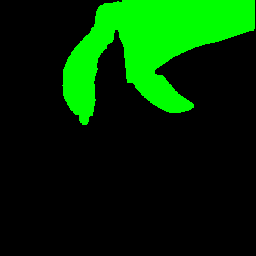

tensor([1, 1, 2, 2, 1, 1, 0, 1, 1, 2, 1, 2, 2, 1, 0, 2, 2, 2, 2, 2])


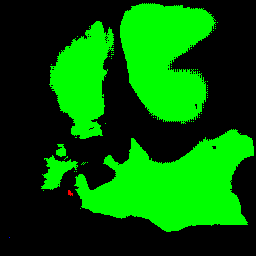

0 20 torch.Size([20])


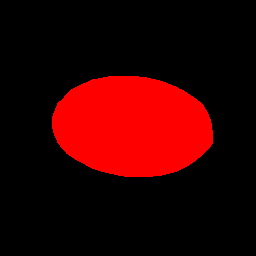

tensor([0, 1, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 1, 1, 1, 0, 2, 0, 1, 0])


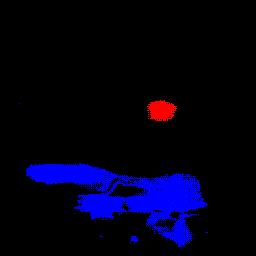

20 40 torch.Size([20])


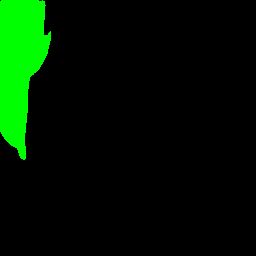

tensor([1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 2, 1, 2, 0, 0, 0, 1, 2, 1, 2])


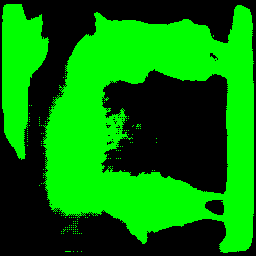

40 60 torch.Size([20])


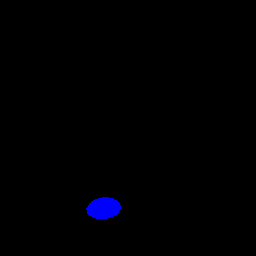

tensor([2, 2, 0, 1, 0, 1, 1, 1, 0, 2, 2, 0, 2, 2, 1, 1, 0, 1, 1, 1])


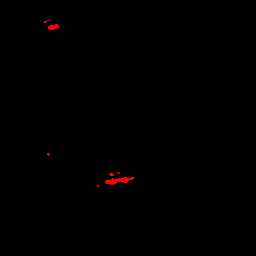

60 80 torch.Size([20])


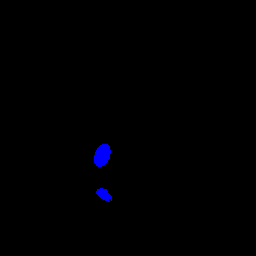

tensor([2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 0, 2, 0, 2, 1, 1, 1, 1, 2])


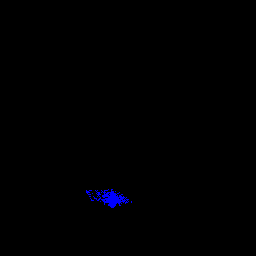

80 100 torch.Size([20])


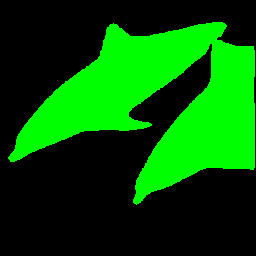

tensor([1, 2, 0, 2, 1, 0, 2, 2, 2, 2, 1, 2, 0, 0, 1, 2, 2, 0, 2, 1])


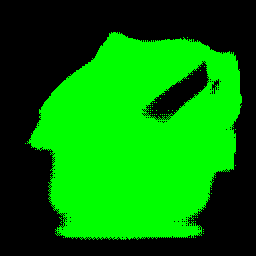

100 120 torch.Size([20])


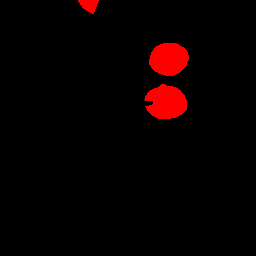

tensor([0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 0, 2, 1, 0, 1, 1, 0, 0, 1])


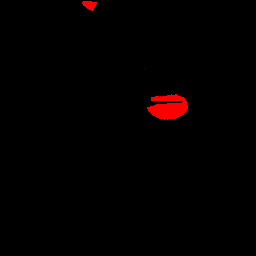

120 140 torch.Size([20])


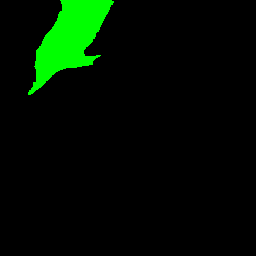

tensor([1, 0, 0, 1, 2, 0, 2, 0, 0, 1, 2, 0, 2, 0, 2, 1, 2, 1, 1, 1])


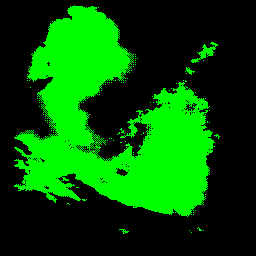

140 160 torch.Size([20])


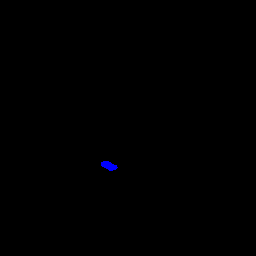

tensor([2, 0, 0, 1, 2, 2, 0, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 1, 0, 2])


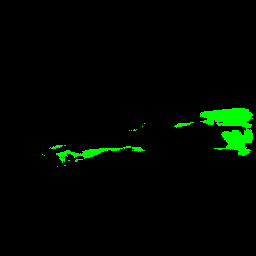

160 180 torch.Size([20])


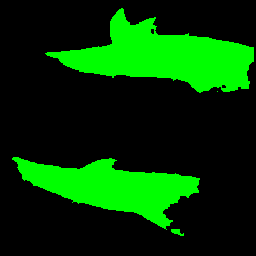

tensor([1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 0, 1, 1, 2, 0, 1, 1, 2, 1, 2])


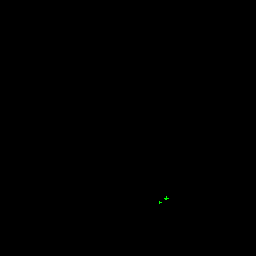

180 200 torch.Size([20])


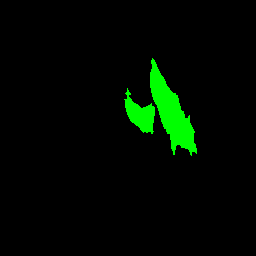

tensor([1, 1, 1, 0, 0, 2, 0, 0, 1, 0, 2, 1, 1, 1, 2, 0, 1, 1, 0, 1])


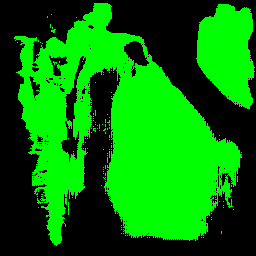

200 220 torch.Size([20])


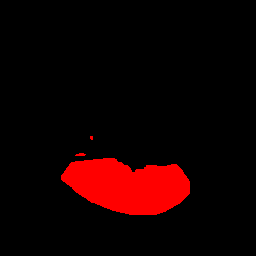

tensor([0, 0, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 2, 0, 2, 2, 1, 1])


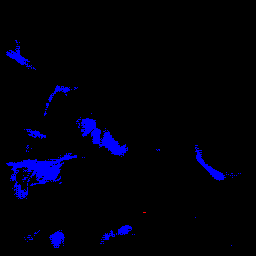

220 240 torch.Size([20])


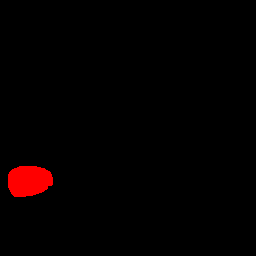

tensor([0, 1, 0, 2, 1, 1, 0, 1, 1, 0, 2, 2, 0, 2, 2, 2, 0, 1, 1, 0])


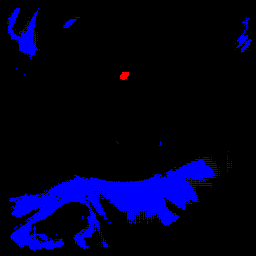

240 260 torch.Size([20])


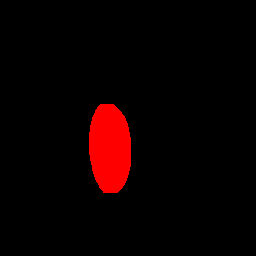

tensor([0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 2])


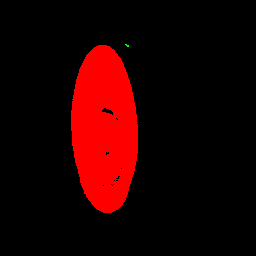

260 280 torch.Size([20])


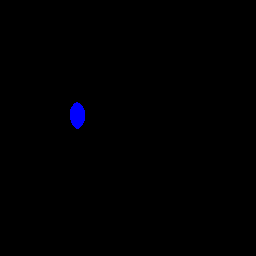

tensor([2, 0, 2, 1, 1, 1, 1, 0, 0, 0, 2, 1, 1, 0, 2, 2, 2, 1, 1, 2])


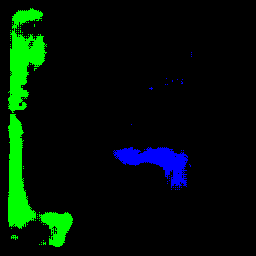

280 300 torch.Size([20])


In [ ]:
def get_results(loader, model):
  dataset_size = len(loader) * loader.batch_size
  probs = np.empty((dataset_size, 3, 256, 256), dtype=np.float32)
  numpy_labels = np.empty((dataset_size, 3, 256, 256), dtype=np.uint8)
  classes = np.empty((dataset_size), dtype=np.uint8)
  softmax = nn.Softmax(dim=1)
  model.eval()
  i = 0
  error = 0
  with torch.no_grad():
    for inputs, labels, class_index in loader:
      next_i = i + inputs.shape[0]
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)
      probs[i : next_i] = softmax(model(inputs)).detach().cpu().numpy()
      numpy_labels[i : next_i] = labels.detach().cpu().numpy()
      # visualization
      print("LABEL")
      display_img_array(numpy_labels[i])
      s = (probs[i] > 0.9).astype(np.uint8)
      print("GUESS")
      display_img_array(s)
      classes[i : next_i] = class_index
      print(i, next_i, class_index.shape)
      i = next_i
  real_result_size = next_i
  return probs, numpy_labels, classes, real_result_size

results = get_results(test_loader, model)

In [ ]:
import pprint
pp = pprint.PrettyPrinter(indent=4, width=80, depth=2)

In [ ]:
def get_metrics(results, threshold=0.9):
  probs, labels, classes, size = results
  # limit last batch results to no trash values
  if probs.shape[0] != size:
    probs = probs[:size]
    labels = labels[:size]
    classes = classes[:size]
  preds = (probs > threshold).astype(np.uint8)
  class_stats = {
      "tp": [0, 0, 0],
      "fp": [0, 0, 0],
      "fn": [0, 0, 0]
  }
  for i in range(size):
    class_stats["tp"][classes[i]] += (preds * labels)[i, classes[i]].sum()
    class_stats["fp"][classes[i]] += (preds * (1 - labels))[i, classes[i]].sum()
    class_stats["fn"][classes[i]] += ((1 - preds) * labels)[i, classes[i]].sum()
  recall = lambda tp, fn: tp / (tp + fn)
  precision = lambda tp, fp: tp / (tp + fp)
  f1 = lambda p, r: 2 * p * r / (p + r)
  tp_sum, fp_sum, fn_sum = sum(class_stats["tp"]), sum(class_stats["fp"]), sum(class_stats["fn"])
  class_stats["recall"] = [recall(tp, fn) for tp, fn in zip(class_stats["tp"], class_stats["fn"])]
  class_stats["precision"] = [precision(tp, fp) for tp, fp in zip(class_stats["tp"], class_stats["fp"])]
  class_stats["f1"] = [f1(p, r) for p, r in zip(class_stats["precision"], class_stats["recall"])]
  dice_coef = 2 * tp_sum / (2 * tp_sum + fp_sum + fn_sum)
  micro_f1 = f1(precision(tp_sum, fp_sum), recall(tp_sum, fn_sum))
  macro_f1 = sum(class_stats["f1"]) / len(class_stats["f1"])
  print(f"Threshold: {threshold}")
  print(f"\tAggregate: TP: {tp_sum}, FP: {fp_sum}, FN: {fn_sum}")
  print(f"\tClasswise:")
  pp.pprint(class_stats)
  print(f"\tDice score: {dice_coef:.4f}")
  print(f"\tF1-macro: {macro_f1:.4f}")
  print(f"\tF1-micro: {micro_f1:.4f}")

for t in [0.8, 0.85, 0.9, 0.95]:
  get_metrics(results, t)

Threshold: 0.8
Aggregate: TP: 1633811.0, FP: 5085015.0, FN: 742117.0
Classwise: {'tp': [486024.0, 647576.0, 500211.0], 'fp': [789820.0, 2729154.0, 1566041.0], 'fn': [299446.0, 342800.0, 99871.0]}
Dice score: 0.3593
F1-macro: 0.3811
F1-micro: 0.3593
Threshold: 0.85
Aggregate: TP: 1484722.0, FP: 3711626.0, FN: 891206.0
Classwise: {'tp': [450390.0, 575297.0, 459035.0], 'fp': [657172.0, 1912193.0, 1142261.0], 'fn': [335080.0, 415079.0, 141047.0]}
Dice score: 0.3921
F1-macro: 0.4079
F1-micro: 0.3921
Threshold: 0.9
Aggregate: TP: 1263233.0, FP: 2136688.0, FN: 1112695.0
Classwise: {'tp': [397189.0, 464323.0, 401721.0], 'fp': [492209.0, 982803.0, 661676.0], 'fn': [388281.0, 526053.0, 198361.0]}
Dice score: 0.4374
F1-macro: 0.4461
F1-micro: 0.4374
Threshold: 0.95
Aggregate: TP: 866259.0, FP: 798991.0, FN: 1509669.0
Classwise: {'tp': [269136.0, 327602.0, 269521.0], 'fp': [262772.0, 313352.0, 222867.0], 'fn': [516334.0, 662774.0, 330561.0]}
Dice score: 0.4287
F1-macro: 0.4345
F1-micro: 0.4287


In [ ]:
torch.save(model.state_dict(), "drive/MyDrive/fiftypoch_scheduler.pth")

In [ ]:
model.load_state_dict(torch.load(
    "drive/MyDrive/unet_model.pth") if torch.cuda.is_available() else torch.load("drive/MyDrive/unet_model.pth", map_location=torch.device('cpu')))
model = model.to(DEVICE)